#### **라이브러리 설치**

In [ ]:
!pip install \
  "numpy>=1.24.0,<2.0.0" \
  "pandas>=2.0.0,<2.3.0" \
  "matplotlib>=3.7.0,<3.10.0" \
  "seaborn>=0.12.0,<0.14.0" \
  "koreanize-matplotlib>=0.1.1" \
  "scikit-learn>=1.2.0,<1.6.0" \
  "torch>=2.0.0,<2.6.0" \
  "kagglehub"

#### **model**

In [4]:
import torch
from torch import nn

# weight, bias를 PyTorch가 자동으로 추적하도록, nn.Module 상속
class SimpleLinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        # 학습한 내용이 날아가지 않도록, layer는 __init__()에서 생성
        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # weight가 2차원 텐서이므로, x도 2차원 텐서여야 함
        if x.ndim == 1:
            x = x.unsqueeze(1)  # 차원 확장 ([100] -> [100, 1])

        return self.linear_layer(x)

#### **Dataset**

In [1]:
from torch.utils.data import Dataset, DataLoader
import torch

class SalaryDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        # nn.Linear output 차원에 맞춰야 함(2차원)
        # -1은 와일드카드
        self.y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [2]:
import kagglehub
from pathlib import Path
from sklearn.model_selection import train_test_split
import pandas as pd

download_path = Path(kagglehub.dataset_download("ishank2005/slary-data"))
csv_file = next(download_path.glob("*.csv"))

df = pd.read_csv(csv_file)

X_raw = df[["YearsExperience"]].values
y_raw = df[["Salary"]].values

# train : val : test = 70 : 15 : 15
X_train, X_temp, y_train, y_temp = train_test_split(X_raw, y_raw, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

train_dataset = SalaryDataset(X_train, y_train)
val_dataset = SalaryDataset(X_val, y_val)
test_dataset = SalaryDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

100%|██████████| 378/378 [00:00<00:00, 248kB/s]

Extracting files...


#### **train**

In [5]:
# 학습
from torch import optim

torch.manual_seed(42)

model = SimpleLinearRegression()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.0001)

EPOCHS = 100

for epoch in range(EPOCHS):
    model.train()  # 모델을 학습 모드로 설정
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)  # nn.Module이 제공하는 전처리, 후처리 기능 등이 모두 정상 작동하도록 model.forward(X)가 아닌 model(X) 호출
        loss = criterion(y_pred, y_batch)  # 예측값, 정답

        optimizer.zero_grad()  # 기울기 리셋
        loss.backward()
        optimizer.step()  # weight, bias 업데이트

        train_loss += loss.item() * len(X_batch)

    avg_train_loss = train_loss / len(train_loader.dataset)

    model.eval()  # 모델을 평가 모드로 설정
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            val_loss += loss.item() * len(X_batch)

        avg_val_loss = val_loss / len(val_loader.dataset)

        if epoch % 20 == 0:
            w = model.linear_layer.weight.item()
            b = model.linear_layer.bias.item()
            print(f"[EPOCH{epoch} / {EPOCHS}] "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f} | "
                  f"Weight: {w:.4f} | bias: {b:.4f}")

print("\n학습 완료!")

[EPOCH0 / 100] Train Loss: 5582081560.3810 | Val Loss: 8992413696.0000 | Weight: 530.5114 | bias: 88.8397
[EPOCH20 / 100] Train Loss: 1336938880.0000 | Val Loss: 2139752704.0000 | Weight: 7207.6250 | bias: 1286.5367
[EPOCH40 / 100] Train Loss: 417594156.1905 | Val Loss: 625956160.0000 | Weight: 10330.5137 | bias: 1915.0709
[EPOCH60 / 100] Train Loss: 218157210.6667 | Val Loss: 293710400.0000 | Weight: 11756.1758 | bias: 2278.2595
[EPOCH80 / 100] Train Loss: 173591616.1190 | Val Loss: 217087984.0000 | Weight: 12405.1152 | bias: 2512.7876

학습 완료!


#### **test**

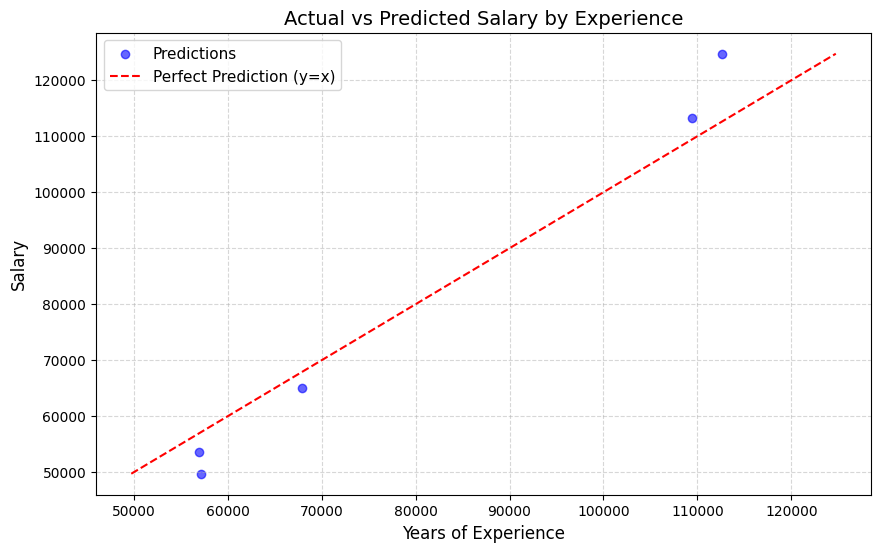

In [6]:
import matplotlib.pyplot as plt

test_y = []
test_y_pred = []

model.eval()  # 모델을 평가 모드로 전환

with torch.no_grad():  # 기울기 계산 및 메모리 추적 비활성화
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)

        test_y.append(y_batch)
        test_y_pred.append(y_pred)

actual_y = torch.cat(test_y, dim=0).cpu().numpy()
pred_y = torch.cat(test_y_pred, dim=0).cpu().numpy()

plt.figure(figsize=(10, 6))

plt.scatter(actual_y, pred_y, alpha=0.6, color="blue", label="Predictions")

min_val = min(actual_y.min(), pred_y.min())
max_val = max(actual_y.max(), pred_y.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Prediction (y=x)")

plt.title('Actual vs Predicted Salary by Experience', fontsize=14)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()